In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from llama_cpp import Llama
import torch
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports done")

✅ Imports done


In [2]:
llm = Llama(
    model_path="./models/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf",
    n_gpu_layers=20,
    n_ctx=2048,
    n_batch=512,
    verbose=False
)
print("✅ Llama loaded")

llama_context: n_ctx_per_seq (2048) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Llama loaded


In [3]:
REVIEW_FILE = "/mnt/c/Users/farha/Downloads/Yelp-JSON/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json"
BUSINESS_FILE = "/mnt/c/Users/farha/Downloads/Yelp-JSON/Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json"

# Load all reviews
print("Loading reviews...")
reviews = []
with open(REVIEW_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            r = json.loads(line)
            reviews.append({
                "business_id": r["business_id"],
                "text": r["text"],
                "stars": r["stars"]
            })
        except json.JSONDecodeError:
            continue

df_reviews = pd.DataFrame(reviews)
print(f"✅ Loaded {len(df_reviews)} total reviews")

# Get top 50 business IDs
top_50_ids = (
    df_reviews.groupby("business_id")
    .size()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

# Load business names
businesses = []
with open(BUSINESS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            b = json.loads(line)
            if b["business_id"] in top_50_ids:
                businesses.append({
                    "business_id": b["business_id"],
                    "name": b.get("name", "Unknown"),
                    "categories": b.get("categories", "")
                })
        except json.JSONDecodeError:
            continue

df_biz = pd.DataFrame(businesses)

# Filter reviews to top 50 only
df_top50 = df_reviews[df_reviews["business_id"].isin(top_50_ids)].copy()
df_top50["sentiment"] = df_top50["stars"].apply(
    lambda x: "positive" if x >= 4 else ("negative" if x <= 2 else "neutral")
)

print(f"✅ Top 50 businesses selected")
print(f"✅ Total reviews in top 50: {len(df_top50)}")
print(f"\nTop 5 preview:")
for bid in top_50_ids[:5]:
    name = df_biz[df_biz["business_id"] == bid]["name"].values
    count = len(df_top50[df_top50["business_id"] == bid])
    print(f"  {name[0] if len(name) > 0 else bid}: {count} reviews")

Loading reviews...
✅ Loaded 6990280 total reviews
✅ Top 50 businesses selected
✅ Total reviews in top 50: 181046

Top 5 preview:
  Acme Oyster House: 7673 reviews
  Oceana Grill: 7516 reviews
  Hattie B’s Hot Chicken - Nashville: 6160 reviews
  Reading Terminal Market: 5778 reviews
  Ruby Slipper - New Orleans: 5264 reviews


In [4]:
print("Loading embedder...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("✅ Embedder loaded")

Loading embedder...
✅ Embedder loaded


In [5]:
def generate_naive(cluster_reviews):
    sample_reviews = cluster_reviews["text"].tolist()[:10]
    reviews_text = "\n".join([f"- {r[:200]}" for r in sample_reviews])
    response = llm.create_chat_completion(
        messages=[
            {
                "role": "system",
                "content": "Generate one concise statement representing the common opinion in these reviews. Output only the statement, nothing else."
            },
            {
                "role": "user",
                "content": f"Reviews:\n{reviews_text}\n\nGenerate one representative statement:"
            }
        ],
        max_tokens=80,
        temperature=0.7
    )
    return response["choices"][0]["message"]["content"].strip()


def generate_bias_aware(cluster_reviews, sentiment):
    sample_reviews = cluster_reviews["text"].tolist()[:10]
    reviews_text = "\n".join([f"- {r[:200]}" for r in sample_reviews])

    if sentiment == "negative":
        instruction = "You MUST focus on complaints, problems, and negative experiences only."
    elif sentiment == "positive":
        instruction = "Focus on praise, strengths, and positive experiences."
    else:
        instruction = "Focus on mixed or moderate opinions."

    response = llm.create_chat_completion(
        messages=[
            {
                "role": "system",
                "content": f"Generate one concise {sentiment} statement from these reviews. {instruction} Output only the statement."
            },
            {
                "role": "user",
                "content": f"Reviews:\n{reviews_text}\n\nGenerate one {sentiment} statement:"
            }
        ],
        max_tokens=80,
        temperature=0.7
    )
    return response["choices"][0]["message"]["content"].strip()

print("✅ Generation functions ready")

✅ Generation functions ready


In [6]:
all_candidates_naive = []
all_candidates_aware = []
all_embeddings = []
all_labels = []
all_samples = []
offset = 0

for biz_idx, biz_id in enumerate(top_50_ids):
    name_row = df_biz[df_biz["business_id"] == biz_id]["name"].values
    biz_name = name_row[0] if len(name_row) > 0 else biz_id

    biz_reviews = df_top50[df_top50["business_id"] == biz_id].copy()

    if len(biz_reviews) < 30:
        print(f"[{biz_idx+1}/50] {biz_name} — skipped (too few reviews)")
        continue

    print(f"[{biz_idx+1}/50] {biz_name} ({len(biz_reviews)} reviews)")

    # Embed
    texts = biz_reviews["text"].tolist()
    embs = embedder.encode(texts, show_progress_bar=False, batch_size=64)
    embs_norm = normalize(embs)

    # Cluster — scale clusters to business size
    n_clusters = min(5, max(2, len(biz_reviews) // 50))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embs_norm)
    biz_reviews = biz_reviews.copy()
    biz_reviews["cluster"] = labels
    biz_reviews["global_cluster"] = labels + offset

    # Generate candidates per cluster
    for i in range(n_clusters):
        cluster_data = biz_reviews[biz_reviews["cluster"] == i]
        dominant = cluster_data["sentiment"].value_counts().index[0]

        naive_stmt = generate_naive(cluster_data)
        aware_stmt = generate_bias_aware(cluster_data, dominant)

        base = {
            "cluster_id": i + offset,
            "business_id": biz_id,
            "business_name": biz_name,
            "cluster_size": len(cluster_data),
            "dominant_sentiment": dominant
        }

        all_candidates_naive.append({**base, "statement": naive_stmt})
        all_candidates_aware.append({**base, "statement": aware_stmt})

    all_embeddings.append(embs_norm)
    all_labels.extend((labels + offset).tolist())
    all_samples.append(biz_reviews)
    offset += n_clusters
    print(f"  ✅ {n_clusters} clusters | naive + aware statements generated")

# Combine
all_embeddings_combined = np.vstack(all_embeddings)
full_sample = pd.concat(all_samples, ignore_index=True)

print(f"\n✅ Pipeline complete")
print(f"✅ Total reviews processed: {len(full_sample)}")
print(f"✅ Total candidate statements: {len(all_candidates_naive)}")

[1/50] Acme Oyster House (7673 reviews)
  ✅ 5 clusters | naive + aware statements generated
[2/50] Oceana Grill (7516 reviews)
  ✅ 5 clusters | naive + aware statements generated
[3/50] Hattie B’s Hot Chicken - Nashville (6160 reviews)
  ✅ 5 clusters | naive + aware statements generated
[4/50] Reading Terminal Market (5778 reviews)
  ✅ 5 clusters | naive + aware statements generated
[5/50] Ruby Slipper - New Orleans (5264 reviews)
  ✅ 5 clusters | naive + aware statements generated
[6/50] Mother's Restaurant (5254 reviews)
  ✅ 5 clusters | naive + aware statements generated
[7/50] Royal House (5146 reviews)
  ✅ 5 clusters | naive + aware statements generated
[8/50] Commander's Palace (4969 reviews)
  ✅ 5 clusters | naive + aware statements generated
[9/50] Luke (4661 reviews)
  ✅ 5 clusters | naive + aware statements generated
[10/50] Cochon (4480 reviews)
  ✅ 5 clusters | naive + aware statements generated
[11/50] Pat's King of Steaks (4293 reviews)
  ✅ 5 clusters | naive + aware stat

In [7]:
def select_slate(candidates, slate_size=5):
    total = sum(c["cluster_size"] for c in candidates)
    selected = []
    remaining = candidates.copy()

    for _ in range(slate_size):
        best = None
        best_score = -1
        for c in remaining:
            already_same = sum(
                1 for s in selected
                if s["dominant_sentiment"] == c["dominant_sentiment"]
            )
            score = (c["cluster_size"] / total) / (1 + already_same)
            if score > best_score:
                best_score = score
                best = c
        if best:
            selected.append(best)
            remaining.remove(best)

    return selected

naive_slate = select_slate(all_candidates_naive, slate_size=5)
aware_slate = select_slate(all_candidates_aware, slate_size=5)
print("✅ Slates selected")

✅ Slates selected


In [8]:
def check_JR(slate, candidates, n, k, theta=0.4):
    min_size = n / k
    violations = []
    results = []

    slate_texts = [s["statement"] for s in slate]
    slate_embs = normalize(embedder.encode(slate_texts))

    for c in candidates:
        if c["cluster_size"] < min_size:
            continue

        cluster_rows = full_sample[
            full_sample["global_cluster"] == c["cluster_id"]
        ]
        if len(cluster_rows) == 0:
            continue

        cluster_embs = all_embeddings_combined[cluster_rows.index]
        sims = cosine_similarity(cluster_embs, slate_embs)
        max_sim = float(sims.max())
        approved = max_sim >= theta

        results.append({
            "cluster_id": c["cluster_id"],
            "business_name": c["business_name"],
            "cluster_size": c["cluster_size"],
            "sentiment": c["dominant_sentiment"],
            "max_similarity": round(max_sim, 3),
            "represented": approved
        })

        if not approved:
            violations.append(c["cluster_id"])

    coverage = round(
        (len(results) - len(violations)) / len(results), 3
    ) if results else 0

    return {
        "satisfies_JR": len(violations) == 0,
        "violations": violations,
        "violation_count": len(violations),
        "coverage": coverage,
        "details": results
    }

n = len(full_sample)
k = 5

naive_jr = check_JR(naive_slate, all_candidates_naive, n, k)
aware_jr = check_JR(aware_slate, all_candidates_aware, n, k)

print("=" * 60)
print("JR EVALUATION RESULTS")
print("=" * 60)
print(f"Naive Llama:      JR={'✅' if naive_jr['satisfies_JR'] else '❌'} | Coverage={naive_jr['coverage']} | Violations={naive_jr['violation_count']}")
print(f"Bias-aware Llama: JR={'✅' if aware_jr['satisfies_JR'] else '❌'} | Coverage={aware_jr['coverage']} | Violations={aware_jr['violation_count']}")

JR EVALUATION RESULTS
Naive Llama:      JR=✅ | Coverage=0 | Violations=0
Bias-aware Llama: JR=✅ | Coverage=0 | Violations=0


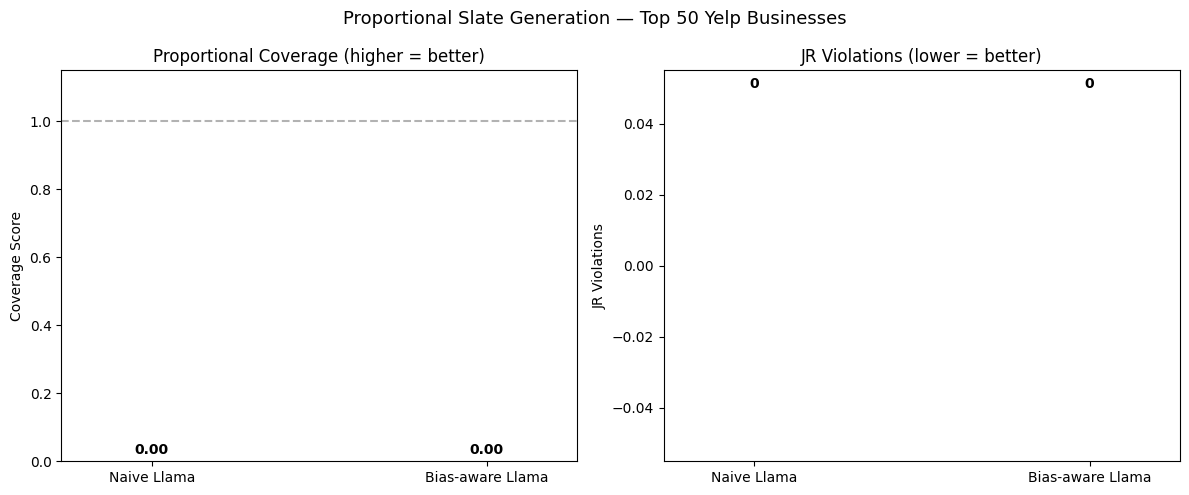

✅ Results saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ["Naive Llama", "Bias-aware Llama"]
coverages = [naive_jr["coverage"], aware_jr["coverage"]]
violations = [naive_jr["violation_count"], aware_jr["violation_count"]]
colors = ["#ff6b6b", "#51cf66"]

# Coverage
bars = axes[0].bar(models, coverages, color=colors, width=0.4)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Coverage Score")
axes[0].set_title("Proportional Coverage (higher = better)")
axes[0].axhline(y=1.0, color="black", linestyle="--", alpha=0.3)
for bar, val in zip(bars, coverages):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.2f}", ha="center", fontweight="bold"
    )

# Violations
bars2 = axes[1].bar(models, violations, color=colors, width=0.4)
axes[1].set_ylabel("JR Violations")
axes[1].set_title("JR Violations (lower = better)")
for bar, val in zip(bars2, violations):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        str(val), ha="center", fontweight="bold"
    )

plt.suptitle("Proportional Slate Generation — Top 50 Yelp Businesses", fontsize=13)
plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()
print("✅ Results saved")

In [10]:
def print_slate(title, slate, jr):
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"JR: {'✅ YES' if jr['satisfies_JR'] else '❌ NO'} | Coverage: {jr['coverage']}")
    print("=" * 60)
    for i, s in enumerate(slate, 1):
        print(f"\n{i}. [{s['dominant_sentiment'].upper()}] {s['statement']}")
        print(f"   Business: {s['business_name']} | {s['cluster_size']} reviews")

print_slate("NAIVE LLAMA SLATE", naive_slate, naive_jr)
print_slate("BIAS-AWARE LLAMA SLATE", aware_slate, aware_jr)

# Save results
import json
output = {
    "total_reviews": n,
    "total_businesses": 50,
    "slate_size": k,
    "naive_llama": {
        "slate": [s["statement"] for s in naive_slate],
        "jr": naive_jr
    },
    "bias_aware_llama": {
        "slate": [s["statement"] for s in aware_slate],
        "jr": aware_jr
    }
}
with open("results.json", "w") as f:
    json.dump(output, f, indent=2)

print("\n✅ Results saved to results.json")
print("✅ Full pipeline complete")


NAIVE LLAMA SLATE
JR: ✅ YES | Coverage: 0

1. [POSITIVE] Opinions about Oceana's food vary, but the overall experience is often let down by inconsistent quality, with some dishes receiving high praise but others receiving criticism for being overcooked, over-sauced, or lacking in flavor.
   Business: Oceana Grill | 2538 reviews

2. [POSITIVE] The chargrilled oysters are a standout dish at this restaurant, with many reviewers praising their flavor and worthiness of the wait.
   Business: Acme Oyster House | 2529 reviews

3. [NEGATIVE] Mother's seems to be inconsistent in quality, relying heavily on its reputation rather than consistently providing good food and service.
   Business: Mother's Restaurant | 1109 reviews

4. [POSITIVE] Oceana is a great restaurant offering consistently delicious food and excellent service in a welcoming atmosphere.
   Business: Oceana Grill | 2005 reviews

5. [NEGATIVE] Geno's is an average cheese steak option that, while not bad, fails to live up to the h